<a href="https://colab.research.google.com/github/vad-source/AIMLROBOTICS/blob/main/Motion%20Model/Comparison_of_Motion_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## AIMLROBOTICS
**Designed by:** RAJA VADHANA PRABHAKAR  
**Organization:** BITS PILANI WILP  
**Purpose:** Academic Training / Proof of Concept  

---
#### Attribution & AI Disclosure
- **Original Design:** The logic, architecture, and modular structure of this notebook were designed by the author.
- **Development Assistance:** Generative AI (e.g., ChatGPT/Claude/Copilot) was used for coding implementation and debugging support.
- **License:** This work is licensed under the [Apache License 2.0](https://apache.org).

**Objective:**
>> To familiarize with the notion of motion models with noise

>> Assume a mobile robot is moving 10 steps. At each step working of each of the below motion model to update the pose is displayed for comparitive analysis

## Install dependencies

In [ ]:
#!pip uninstall -y dopamine-rl
!pip install gymnasium==0.28.1 shimmy==0.2.1 stable-baselines3==2.0.0 matplotlib

  Using cached Shimmy-0.2.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached stable_baselines3-2.0.0-py3-none-any.whl.metadata (5.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.5/925.5 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.4/178.4 kB 12.5 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.2.1
    Uninstalling gymnasium-1.2.1:
      Successfully uninstalled gymnasium-1.2.1
  Attempting uninstall: stable-baselines3
    Found existing installation: stable_baselines3 2.7.0
    Uninstalling stable_baselines3-2.7.0:
      Successfully uninstalled stable_baselines3-2.7.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.28.1 whic

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from stable_baselines3 import PPO

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Define the Environment

In [ ]:
class Simple2DRobotEnv(gym.Env):
    def __init__(self):
        super(Simple2DRobotEnv, self).__init__()
        self.observation_space = spaces.Box(low=-10, high=10, shape=(2,), dtype=np.float32)
        self.action_space = spaces.Box(low=-1, high=1, shape=(2,), dtype=np.float32)
        self.state = np.array([0.0, 0.0])
        self.goal = np.array([5.0, 5.0])  #Used only in RL

    def reset(self, *, seed=None, options=None):
        self.state = np.array([0.0, 0.0])
        return self.state, {}

    def step(self, action):
        self.state = self.state + action
        dist = np.linalg.norm(self.goal - self.state)
        reward = -dist
        terminated = False  #In RL if exploration must be stopped after it reaches near goal set  terminated = dist < 0.1
        truncated = False
        return self.state, reward, terminated, truncated, {}

# Motion Models

## Velocity


In [ ]:
def velocity_motion_model(state, control, noise_std):
    noise = np.random.normal(0, noise_std, size=2)
    return state + control + noise

## Odometry

In [ ]:
def odometry_motion_model(state, wheel_displacements, noise_std):
    forward = np.mean(wheel_displacements)
    rotation = (wheel_displacements[1] - wheel_displacements[0]) * 0.1
    noise = np.random.normal(0, noise_std, size=2)
    return state + np.array([forward, rotation]) + noise

## Gaussian

In [ ]:
def gaussian_motion_model(state, control, noise_cov):
    noise = np.random.multivariate_normal([0,0], noise_cov)
    return state + control + noise, noise_cov

## Sampling

In [ ]:
def sampling_motion_model(state, control, noise_std, num_particles):
    particles = []
    for _ in range(num_particles):
        noise = np.random.normal(0, noise_std, size=2)
        particles.append(state + control + noise)
    return np.array(particles)

## Linear Pretrained Model

In [ ]:
class AIMotionModel:
    def __init__(self):
        self.W = np.array([[0.95, 0.05],
                           [0.03, 0.97]])
        self.bias = np.array([0.03, -0.02])

    def predict(self, state, control):
        return state + self.W.dot(control) + self.bias

## ReinforcementLearner

In [ ]:
env = Simple2DRobotEnv()
model = PPO("MlpPolicy", env, verbose=0)
model.learn(total_timesteps=10000)

def ai_motion_model(state):
    action, _ = model.predict(state, deterministic=False)
    return state + action

# Simulate the motion

In [ ]:
steps = 10
control = np.array([1.0, 0.5])  # move right and up
state = np.array([0.0, 0.0])
num_particles = 100

vel_traj, odo_traj, gauss_traj, ml_ai_traj, rl_ai_traj = [], [], [], [], []
gauss_covs = []
sampling_traj = []

state = np.array([0.0, 0.0])

for t in range(steps):
    # Noise grows with time (e.g., 0.1 * step)
    noise_std = 0.1 + 0.05*t
    noise_cov = np.diag([noise_std, noise_std])
    #noise_std = 0.2
    #noise_cov=np.diag([0.2,0.2])

    # Velocity
    state_vel = velocity_motion_model(state if t==0 else vel_traj[-1], control,noise_std)
    vel_traj.append(state_vel)

    # Odometry
    state_odo = odometry_motion_model(state if t==0 else odo_traj[-1], [1.0, 1.2],noise_std)
    odo_traj.append(state_odo)

    # Gaussian
    state_gauss, cov = gaussian_motion_model(state if t==0 else gauss_traj[-1], control,noise_cov)
    gauss_traj.append(state_gauss)
    gauss_covs.append(cov)

    # Sampling
    if t == 0:
        particles = sampling_motion_model(state, control,noise_std, num_particles)
    else:
        # Use mean of previous particles as "next state"
        particles = sampling_motion_model(sampling_traj[-1].mean(axis=0), control,noise_std, num_particles)
    #particles = sampling_motion_model(state if t==0 else (sampling_traj[-1].mean(axis=0)), control, num_particles=200)
    sampling_traj.append(particles)



    # AI/ML
    ai = AIMotionModel()
    s_ai = ai.predict(state if t == 0 else ml_ai_traj[-1], control)
    ml_ai_traj.append(s_ai)

    state_ai = ai_motion_model(state if t==0 else rl_ai_traj[-1])
    rl_ai_traj.append(state_ai)


## Visualize the behaviour

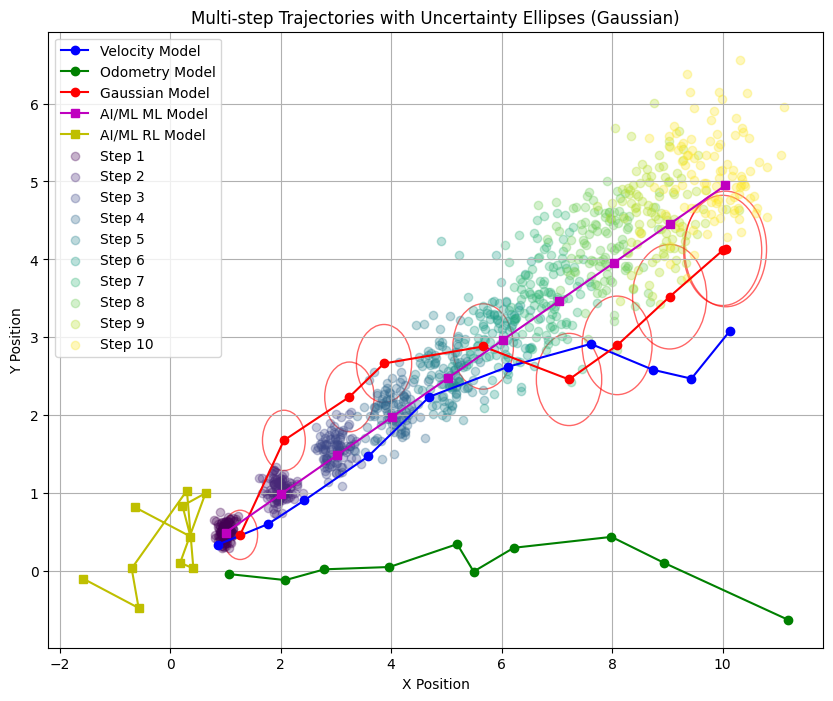

In [ ]:
plt.figure(figsize=(10,8))

vel_traj = np.array(vel_traj)
odo_traj = np.array(odo_traj)
gauss_traj = np.array(gauss_traj)
ml_ai_traj = np.array(ml_ai_traj)
rl_ai_traj = np.array(rl_ai_traj)

plt.plot(vel_traj[:,0], vel_traj[:,1], 'b-o', label='Velocity Model')
plt.plot(odo_traj[:,0], odo_traj[:,1], 'g-o', label='Odometry Model')
plt.plot(gauss_traj[:,0], gauss_traj[:,1], 'r-o', label='Gaussian Model')
plt.plot(ml_ai_traj[:,0], ml_ai_traj[:,1], 'm-s', label='AI/ML ML Model')
plt.plot(rl_ai_traj[:,0], rl_ai_traj[:,1], 'y-s', label='AI/ML RL Model')

# Add uncertainty ellipses for Gaussian model at each step
for i, (mean, cov) in enumerate(zip(gauss_traj, gauss_covs)):
    ellipse = patches.Ellipse(xy=mean, width=2*np.sqrt(cov[0,0]), height=2*np.sqrt(cov[1,1]),
                              edgecolor='r', fc='None', lw=1, alpha=0.6)
    plt.gca().add_patch(ellipse)

# Plot sampling particles at final step
colors = plt.cm.viridis(np.linspace(0,1,steps))

for i, particles in enumerate(sampling_traj):
    plt.scatter(particles[:,0], particles[:,1], alpha=0.3, color=colors[i], label=f"Step {i+1}")

#plt.scatter(sampling_traj[-1][:,0], sampling_traj[-1][:,1], alpha=0.3, label='Sampling Model (final step)')

plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.title("Multi-step Trajectories with Uncertainty Ellipses (Gaussian)")
plt.legend()
plt.grid(True)
plt.show()


## Save the result

### Installtions

In [ ]:
!pip install matplotlib ipywidgets
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import ipywidgets as widgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.8 MB/s eta 0:00:00


### Plot

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(-1, steps * control[0] + 2)
ax.set_ylim(-1, steps * control[1] + 2)
ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")
ax.set_title("Step-by-step Animation: Motion Models Comparison")
ax.grid(True)

# Lines and markers for trajectories
vel_line, = ax.plot([], [], 'b-o', label='Velocity')
odo_line, = ax.plot([], [], 'g-o', label='Odometry')
gauss_line, = ax.plot([], [], 'r-o', label='Gaussian')
ml_ai_line,   = ax.plot([], [], 'm-s', label='AI/ML')
rl_ai_line,   = ax.plot([], [], 'y-s', label='AI/RL')

# Gaussian uncertainty ellipse
ellipse = patches.Ellipse((0, 0), 0.0, 0.0, edgecolor='r', fc='None', lw=1.5, alpha=0.7)
ax.add_patch(ellipse)

# Sampling particles scatter (updated each frame)
scatter = ax.scatter([], [], s=15, alpha=0.25, label='Sampling particles')

ax.legend(loc='upper left')

def init():
    vel_line.set_data([], [])
    odo_line.set_data([], [])
    gauss_line.set_data([], [])
    ml_ai_line.set_data([], [])
    rl_ai_line.set_data([], [])
    scatter.set_offsets(np.empty((0, 2)))
    ellipse.set_visible(False)
    return vel_line, odo_line, gauss_line, ml_ai_line, rl_ai_line, scatter, ellipse

def update(frame):
    # Up to current frame (inclusive)
    xs_vel, ys_vel = vel_traj[:frame+1, 0], vel_traj[:frame+1, 1]
    xs_odo, ys_odo = odo_traj[:frame+1, 0], odo_traj[:frame+1, 1]
    xs_gauss, ys_gauss = gauss_traj[:frame+1, 0], gauss_traj[:frame+1, 1]
    xs_aiml, ys_aiml = ml_ai_traj[:frame+1, 0], ml_ai_traj[:frame+1, 1]
    xs_airl, ys_airl = rl_ai_traj[:frame+1, 0], rl_ai_traj[:frame+1, 1]

    vel_line.set_data(xs_vel, ys_vel)
    odo_line.set_data(xs_odo, ys_odo)
    gauss_line.set_data(xs_gauss, ys_gauss)
    ml_ai_line.set_data(xs_aiml, ys_aiml)
    rl_ai_line.set_data(xs_airl, ys_airl)

    # Update sampling particles for this step
    particles = sampling_traj[frame]
    scatter.set_offsets(particles)

    # Update Gaussian uncertainty ellipse at current mean
    mean = gauss_traj[frame]
    cov = gauss_covs[frame]
    width = 2 * np.sqrt(cov[0, 0])
    height = 2 * np.sqrt(cov[1, 1])
    ellipse.center = mean
    ellipse.width = width
    ellipse.height = height
    ellipse.set_visible(True)

    return vel_line, odo_line, gauss_line, ml_ai_line, rl_ai_line, scatter, ellipse

anim = FuncAnimation(fig, update, frames=steps, init_func=init, interval=600, blit=True)
plt.close()

is_running = True

def toggle_run(change):
    global is_running
    if is_running:
        anim.event_source.stop()
        button.description = "▶️ Resume"
    else:
        anim.event_source.start()
        button.description = "⏸️ Pause"
    is_running = not is_running

button = widgets.Button(description="⏸️ Pause")
button.on_click(toggle_run)

display(button)
HTML(anim.to_jshtml())

Button(description='⏸️ Pause', style=ButtonStyle())